# Assignment 1: Wrangling and EDA
### Foundations of Machine Learning

In [13]:
# get data

import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

**Q1.** This question provides some practice cleaning variables which have common problems.
1. Numeric variable: For `airbnb_NYC.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)

The `Price` variable is originally of type string, so I first removed the commas from the values greater than 999. Afterwards, I converted the values to type int. If I had instead just directly converted to int and dropped "invalid" values, we would have lost all rows with price greater than 999.  

2. Categorical variable: For the Minnesota police use of for data, `mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? For the remaining missing values, replace the `np.nan/None` values with the label `Missing`.

The proportion of missing values is 0.7619. One of the biggest patterns visible with the `force_type` variable is that most of the NaN values are bodily force (7051 NaN versus 2379 yeses and nos), chemical irritants (1421 versus 172 yeses and nos), and maximal restraint techniques (170 NaN versus **0** yeses and nos). To erase these NaN values simply because they are missing contributes to a skewed narrative about the level of unnecessary force exerted by Minnesota police.

3. Dummy variable: For `metabric.csv`, convert the `Overall Survival Status` variable into a dummy/binary variable, taking the value 0 if the patient is deceased and 1 if they are living.

Completed below.

4. Missing values: For `airbnb_NYC.csv`, determine how many missing values of `Review Scores Rating` there are. Create a new variable, in which you impute the median score for non-missing observations to the missing ones. Why might this bias or otherwise negatively impact your results?

For the missing values, just using the median value could skew the impression behind the data. For instance, if the missing values are missing because they are smaller, less popular AirBnB locations, assigning the median values would distort this variable. Additionally, because so many values are highly similar, it would be difficult to determine correlation with other variables.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1, 4
df = pd.read_csv("data/airbnb_NYC.csv", encoding="latin1")
print("BEFORE: "+ str(type(df["Price"][0]))) # price is a string, want to convert to int
print(df["Price"].describe())
df["Price"] = df["Price"].str.replace(",",'')
df["Price"] = df["Price"].astype(int)
print("AFTER: " + str(type(df["Price"][0]))) # verify that type is now int
print(df["Price"].describe())
df["Price"].isna().sum()

df["Review Scores Rating"].isna().sum()
median_rating = df["Review Scores Rating"].median()
df["Review_Scores_Rating_imputed"] = (
    df["Review Scores Rating"]
    .fillna(median_rating)
)
df["Review_Scores_Rating_imputed"].isna().sum()

print('--------')
# 2
df = pd.read_csv("data/mn_police_use_of_force.csv")
print(df["subject_injury"].isna().sum()) # shows that there are 9848 null values
# print(df["subject_injury"].describe())
print(df["subject_injury"].value_counts(dropna=False)) # verifies the amount of each value
print(pd.crosstab(df["subject_injury"], df["force_type"], dropna=False)) # cross tabulation of values
print('-----')
print(df.loc[df["subject_injury"].isna(), "force_type"].value_counts())
df["subject_injury_clean"] = df["subject_injury"].fillna("Missing") # replace NA with Missing
print('-----')
pd.crosstab(df["subject_injury_clean"], df["force_type"]) # cross tabulation after cleaning

print('--------')
# 3
df = pd.read_csv("data/metabric.csv")
print(df["Overall Survival Status"].value_counts())
df["Overall_Survival_Status_dummy"] = (df["Overall Survival Status"].map({"1:DECEASED": 0,"0:LIVING": 1}))
print(df["Overall_Survival_Status_dummy"].value_counts())

BEFORE: <class 'str'>
count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object
AFTER: <class 'numpy.int64'>
count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price, dtype: float64
--------
9848
subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64
force_type      Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury                                                    
No                  0          1093                131        2   
Yes                 2          1286                 41        0   
NaN                 2          7051               1421        0   

force_type      Gun Point Display  Improvised Weapon  Less Lethal  \
subject_injury                                                      
No                             33                 34            0   
Yes                 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks.

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work. What does work?
2. Drop any columns that do not contain data.
3. What is an observation? Carefully justify your answer, and explain how it affects your choices in cleaning and analyzing the data.
4. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
5. Clean the Age variable and make a histogram of the ages of the victims.
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?
7. Clean the `Fatal Y/N` variable so it only takes three values: Y, N, and Unknown.
8. Is the attack more or less likely to be fatal when the attack is provoked or unprovoked? Thoughts?

**Q3.** Open the "tidy_data.pdf" document available in `https://github.com/ds4e/wrangling`, which is a paper called *Tidy Data* by Hadley Wickham.

 **1. Read the abstract. What is this paper about?**

 The paper is about streamlining the data cleaning process, specifically the data tidying process, which classifies each variable as a column and every observation as a row.

  **2. Read the introduction. What is the "tidy data standard" intended to accomplish?**

The tidy data standard accomplishes a set system to INCOMPLETE

  **3. Read the intro to section 2. What does this sentence mean: "Like families, tidy datasets are all alike but every messy dataset is messy in its own way." What does this sentence mean: "For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general."**

"Like families, tidy datasets are all alike but every messy dataset is messy in its own way.": Tidy datasets are often structured in a similar way that promotes readability and is set up for data analysis, while messy datasets each have a unique set of problems that prevent it from being tidy.

"For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general.": INCOMPLETE

  **4. Read Section 2.2. How does Wickham define values, variables, and observations?**

Values: numbers or strings

Variables: Contains all values measuring the same underlying attribute across different observations

Observations: Contains all values related to the same unit (like a person or point in time)

  **5. How is "Tidy Data" defined in section 2.3?**

Tidy data is a standard way of structuring a dataset, adhering to the following constraints: every variable forms a column, every observation forms a row, and each type of observational unit forms a table.

  **6. Read the intro to Section 3 and Section 3.1. What are the 5 most common problems with messy datasets? Why are the data in Table 4 messy? What is "melting" a dataset?**

5 most common problems: column headers being values and not variable names, multiple variables stored in one column, variables stored in both rows and columns, multiple types of observational units stored in the same table, and a single observational unit is stored in multiple tables.

Table 4's data is messy because it contains three variables (religion, income, frequency) but is not formatted accordingly.

  **7. Why, specifically, is table 11 messy but table 12 tidy and "molten"?**

  Table 11 is messy because there are multiple observational units being stored in one table, leading to a bunch of missing values. Table 12 is tidy because it separates these multiple observational units into distinct tables. The tidy table also limits every unique day to be one row, as opposed to multiple rows, promoting readability.

**Q4.** This question looks at financial transfers from international actors to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going?

For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.

From the variable description, we can see that 75% of the values are below \$ 376142, with a max of $100,000,000. Additionally, there is a minimum value of a negative value, which may be a fluke in data collection. The histogram was converted to log scale for easier interpretation, which shows that as the values increase, the instances decrease.

3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?

Contracts are 61.21% of gifts, real estate is 38.75%, and monetary gifts are a mere 0.03898%.

4. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?

In terms of the number of gifts, the top 15 countries are England, China, Canada, Japan, Switzerland, Saudi Arabia, France, Germany, Hong Kong, South Korea, Qatar, The Netherlands, Korea, India, and Taiwan (Not sure what the difference is between Korea and South Korea, if Korea is North Korea or otherwise).

The top 15 countries in terms of amount are Qatar, England, China, Saudi Arabia, Bermuda, Canada, Hong Kong, Japan, Switzerland, India, Germany, The UAE, France, Singapore, and Australia. Bermuda is technically an autonomous territory of the UK, so I am unsure of why they are being considered a separate nation in this context.

5. What are the top 15 institutions in terms of the total amount of money they receive? Make a histogram of the total amount received by all institutions.

Completed below. The top 15 institutions are Carnegie Mellon, Cornell, Harvard, MIT, Yale, Texas A&M, Johns Hopkins, Northwestern, Georgetown, UChicago, UC Boulder, Duke, BYU, Stanford, and U Texas MD Anderson Cancer Center.

6. Which giftors provide the most money, in total?

The giftors that provide the most money are described in the chart below. As a collective, the Qatar Foundation provides a staggering 2.33 billion dollars of donations across their subsidiary organizations.


count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64


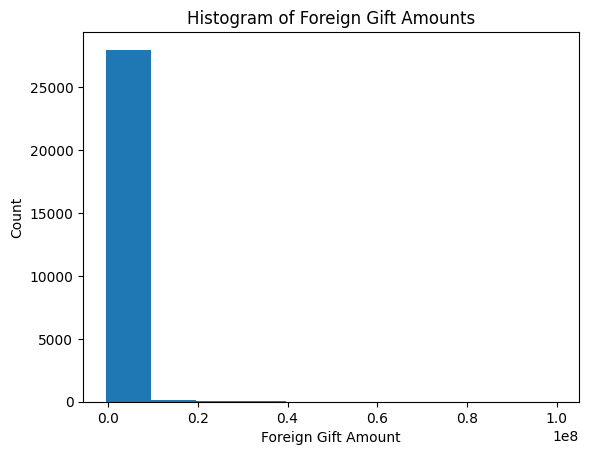

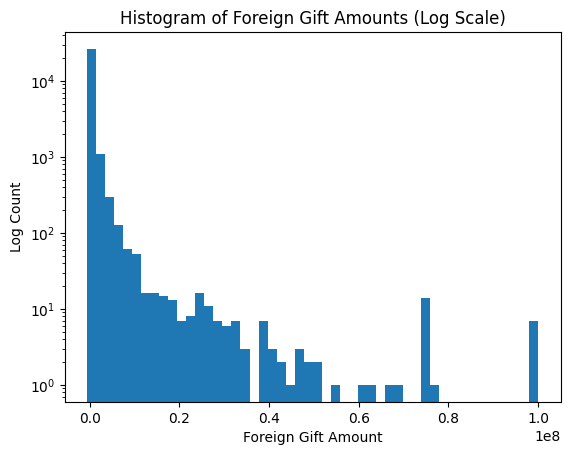

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
-----
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   40583939

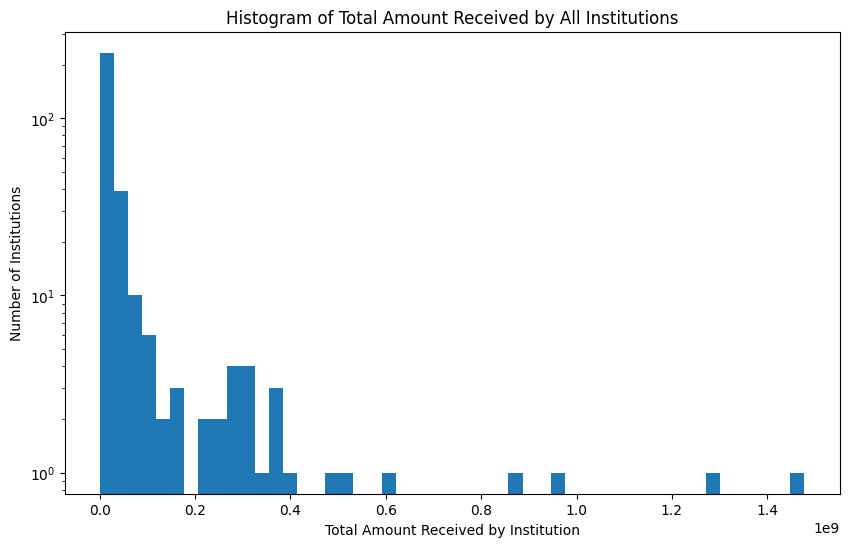

Institution Name
Carnegie Mellon University                       1477922504
Cornell University                               1289937761
Harvard University                                954803610
Massachusetts Institute of Technology             859071692
Yale University                                   613441311
Texas A&M University                              521455050
Johns Hopkins University                          502409595
Northwestern University                           402316221
Georgetown University                             379950511
University of Chicago (The)                       364544338
University of Colorado Boulder                    360173159
Duke University                                   343699498
Brigham Young University                          323509863
Stanford University                               319561362
University of Texas MD Anderson Cancer Center     301527419
Name: Foreign Gift Amount, dtype: int64
-----
Top 15 giftors by total amount given:

In [15]:
# 1
df = pd.read_csv("data/ForeignGifts_edu.csv")

# 2
print(df["Foreign Gift Amount"].describe())

plt.hist(df["Foreign Gift Amount"], bins=10)
plt.xlabel("Foreign Gift Amount")
plt.ylabel("Count")
plt.title("Histogram of Foreign Gift Amounts")
plt.show()

plt.hist(df["Foreign Gift Amount"], bins=50)
plt.yscale("log")
plt.xlabel("Foreign Gift Amount")
plt.ylabel("Log Count")
plt.title("Histogram of Foreign Gift Amounts (Log Scale)")
plt.show()

# 3
gift_counts = df["Gift Type"].value_counts()
print(gift_counts)
print("-----")

# 4
top_countries_count = (
    df.groupby("Country of Giftor")
      .count()["Foreign Gift Amount"]
      .sort_values(ascending=False)
      .head(15)
)
print(top_countries_count)

top_countries_amount = (
    df.groupby("Country of Giftor")
      .sum(numeric_only=True)["Foreign Gift Amount"]
      .sort_values(ascending=False)
      .head(15)
)
print(top_countries_amount)
print("-----")

# 5
institution_totals = df.groupby("Institution Name")["Foreign Gift Amount"].sum()
plt.figure(figsize=(10,6))
plt.hist(institution_totals, bins=50, log=True)  # log scale for skewed data
plt.xlabel("Total Amount Received by Institution")
plt.ylabel("Number of Institutions")
plt.title("Histogram of Total Amount Received by All Institutions")
plt.show()

top_institutions = (
    df.groupby("Institution Name")
      .sum(numeric_only=True)["Foreign Gift Amount"]
      .sort_values(ascending=False)
      .head(15)
)
print(top_institutions)
print('-----')

# 6
top_giftors = (
    df.groupby("Giftor Name")["Foreign Gift Amount"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
)
print("Top 15 giftors by total amount given:\n", top_giftors)

**Q5.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `college_completion.csv` dataset from the US Department of Education. The "relevant" variables for this question are:
  - `level` - Level of institution (4-year, 2-year)
  - `aid_value` - The average amount of student aid going to undergraduate recipients
  - `control` - Public, Private not-for-profit, Private for-profit
  - `grad_100_value` - percentage of first-time, full-time, degree-seeking undergraduates who complete a degree or certificate program within 100 percent of expected time (bachelor's-seeking group at 4-year institutions)

1. Load the `college_completion.csv` data with Pandas.
2. How many observations and variables are in the data? Use `.head()` to examine the first few rows of data.

There are 3798 observations and 63 variables.

3. Cross tabulate `control` and `level`. Describe the patterns you see in words.

This cross-tabulation reveals that about 73% of the 4 year institutions are private (combining for-profit and not-for-profit). Additionally, there are very few private not-for-profit 2 year universities, but a somewhat equal distribution of private for-profit and public universities across both 2-year and 4-year institutions.

4. For `grad_100_value`, create a kernel density plot and describe table. Now condition on `control`, and produce a kernel density plot and describe tables for each type of institutional control. Which type of institution appear to have the most favorable graduation rates?

It seems that private not-for-profit institutions have the most favorable graduation rates, followed closely by private for-profit institutions.

5. Make a scatterplot of `grad_100_value` by `aid_value`, and compute the covariance and correlation between the two variables. Describe what you see. Now make the same plot and statistics, but conditioning on `control`. Describe what you see. For which kinds of institutions does aid seem to vary positively with graduation rates?

Aid varies positively with graduation rates for public institutions, while both for-profit and not-for-profitprivate institutions don't seem to vary with the amount of aid provided.


(3798, 63)
   index  unitid                            chronname        city    state  \
0      0  100654               Alabama A&M University      Normal  Alabama   
1      1  100663  University of Alabama at Birmingham  Birmingham  Alabama   
2      2  100690                   Amridge University  Montgomery  Alabama   
3      3  100706  University of Alabama at Huntsville  Huntsville  Alabama   
4      4  100724             Alabama State University  Montgomery  Alabama   

    level                 control  \
0  4-year                  Public   
1  4-year                  Public   
2  4-year  Private not-for-profit   
3  4-year                  Public   
4  4-year                  Public   

                                               basic hbcu flagship  ...  \
0  Masters Colleges and Universities--larger prog...    X      NaN  ...   
1  Research Universities--very high research acti...  NaN      NaN  ...   
2            Baccalaureate Colleges--Arts & Sciences  NaN      NaN  ... 

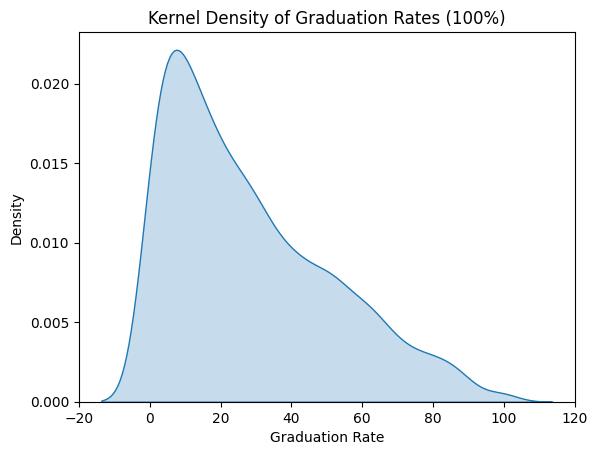

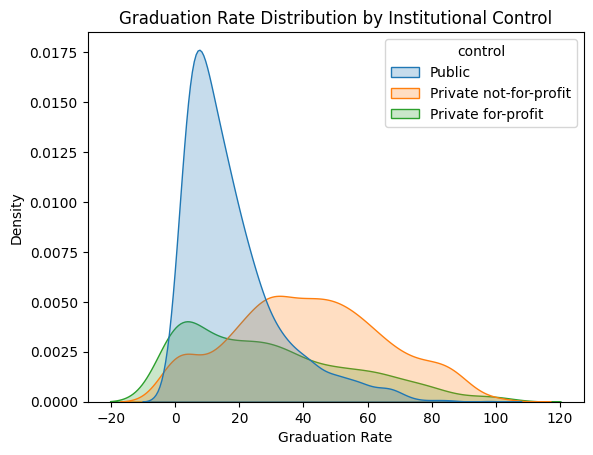

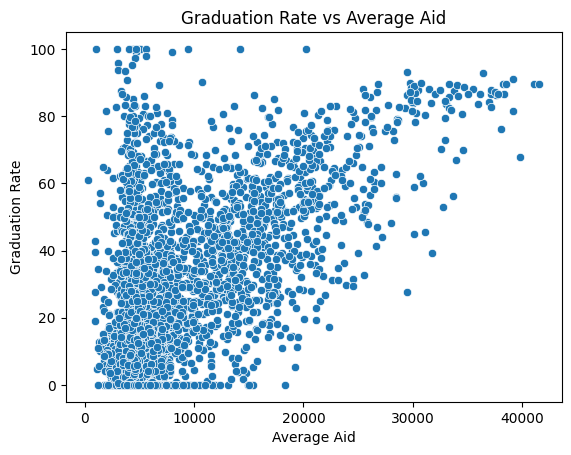

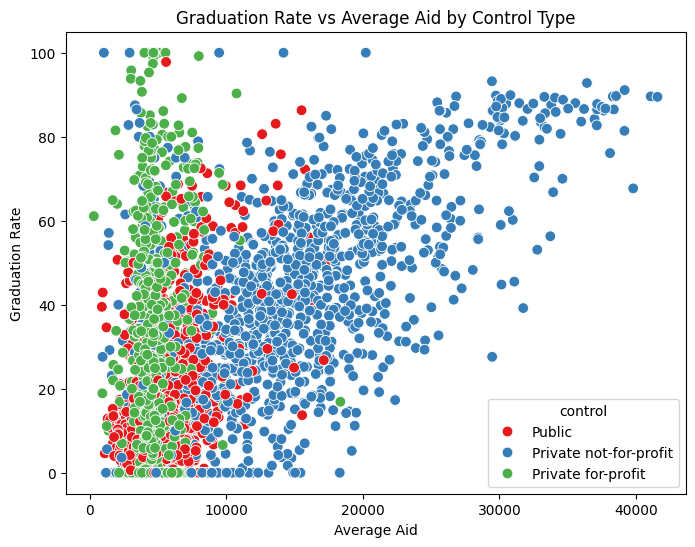

Covariance: 88610.48316902411, Correlation: 0.5758792845936064


In [17]:
# 1
df = pd.read_csv("data/college_completion.csv")

# 2
print(df.shape)
print(df.head())

# 3
print(pd.crosstab(df["control"], df["level"]))

# 4
sns.kdeplot(df['grad_100_value'], fill=True)
plt.title('Kernel Density of Graduation Rates (100%)')
plt.xlabel('Graduation Rate')
plt.ylabel('Density')
plt.show()

sns.kdeplot(data=df, x='grad_100_value', hue='control', fill=True)
plt.title('Graduation Rate Distribution by Institutional Control')
plt.xlabel('Graduation Rate')
plt.ylabel('Density')
plt.show()

df.groupby('control')['grad_100_value'].describe()

# 5
# Overall scatterplot
sns.scatterplot(data=df, x='aid_value', y='grad_100_value')
plt.title('Graduation Rate vs Average Aid')
plt.xlabel('Average Aid')
plt.ylabel('Graduation Rate')
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='aid_value',
    y='grad_100_value',
    hue='control',       # color points by control type
    palette='Set1',      # optional: nicer colors
    s=60                 # optional: marker size
)
plt.title('Graduation Rate vs Average Aid by Control Type')
plt.xlabel('Average Aid')
plt.ylabel('Graduation Rate')
plt.legend(title='control')
plt.show()

# Covariance and correlation
cov = df[['grad_100_value', 'aid_value']].cov().iloc[0,1]
corr = df[['grad_100_value', 'aid_value']].corr().iloc[0,1]
print(f'Covariance: {cov}, Correlation: {corr}')



**Q6.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

We're going to look at **linear transformations** of $X$, $Y = a + bX$. So we take each value of $X$, $x_i$, and transform it as $y_i = a + b x_i$.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $ \text{cov}(X,X) = s^2$.
3. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
4. Show that $\text{cov}(a+bX,a+bY) = b^2 \text{cov}(X,Y) $. Notice, this also means that $\text{cov}(bX, bX) = b^2 s^2$.
5. Suppose $b>0$ and let the median of $X$ be $\text{med}(X)$. Is it true that the median of $a+bX$ is equal to $a + b \times \text{med}(X)$? Is the IQR of $a + bX$ equal to $a + b \times \text{IQR}(X)$?
6. Show by example that the means of $X^2$ and $\sqrt{X}$ are generally not $(m(X))^2$ and $\sqrt{m(X)}$. So, the results we derived above really depend on the linearity of the transformation $Y = a + bX$, and transformations like $Y = X^2$ or $Y = \sqrt{X}$ will not behave in a similar way.

***Images of proof have been uploaded to github.***

**Q7.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `ames_prices.csv` dataset. The "relevant" variables for this question are:
  - `price` - Sale price value of the house
  - `Bldg.Type` - Building type of the house (single family home, end-of-unit townhome, duplex, interior townhome, two-family conversion)

1. Load the `college_completion.csv` data with Pandas.
2. Make a kernel density plot of price and compute a describe table. Now, make a kernel density plot of price conditional on building type, and use `.groupby()` to make a describe type for each type of building. Which building types are the most expensive, on average? Which have the highest variance in transaction prices?
3. Make an ECDF plot of price, and compute the sample minimum, .25 quantile, median, .75 quantile, and sample maximum (i.e. a 5-number summary).
4. Make a boxplot of price. Are there outliers? Make a boxplot of price conditional on building type. What patterns do you see?
5. Make a dummy variable indicating that an observation is an outlier.
6. Winsorize the price variable, and compute a new kernel density plot and describe table. How do the results change?

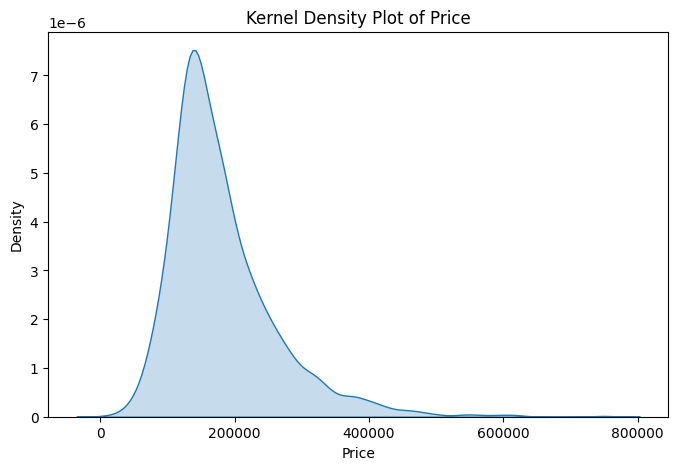

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: price, dtype: float64


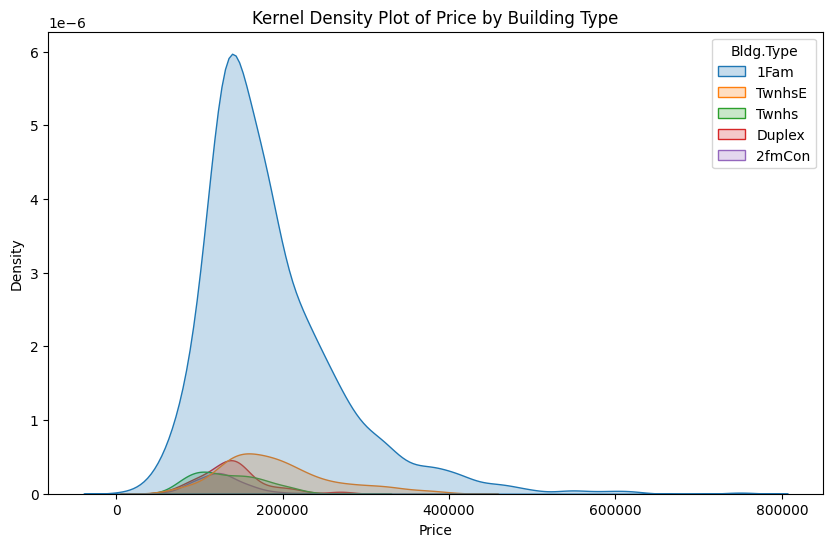

            count           mean           std      min       25%       50%  \
Bldg.Type                                                                     
1Fam       2425.0  184812.041237  82821.802329  12789.0  130000.0  165000.0   
2fmCon       62.0  125581.709677  31089.239840  55000.0  106562.5  122250.0   
Duplex      109.0  139808.935780  39498.973534  61500.0  118858.0  136905.0   
Twnhs       101.0  135934.059406  41938.931130  73000.0  100500.0  130000.0   
TwnhsE      233.0  192311.914163  66191.738021  71000.0  145000.0  180000.0   

                75%       max  
Bldg.Type                      
1Fam       220000.0  755000.0  
2fmCon     140000.0  228950.0  
Duplex     153337.0  269500.0  
Twnhs      170000.0  280750.0  
TwnhsE     222000.0  392500.0  


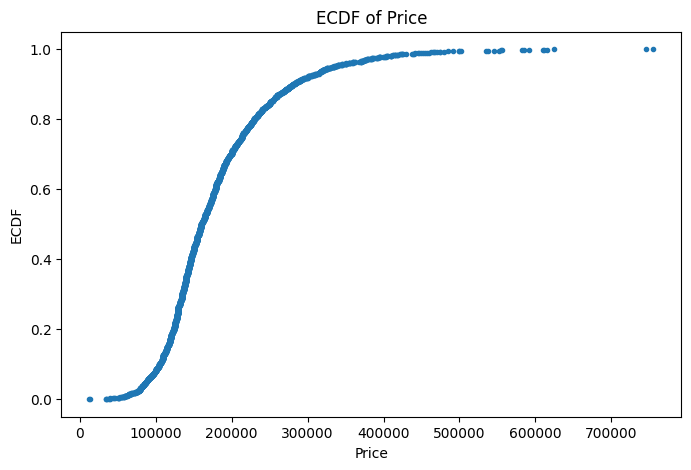

0.00     12789.0
0.25    129500.0
0.50    160000.0
0.75    213500.0
1.00    755000.0
Name: price, dtype: float64


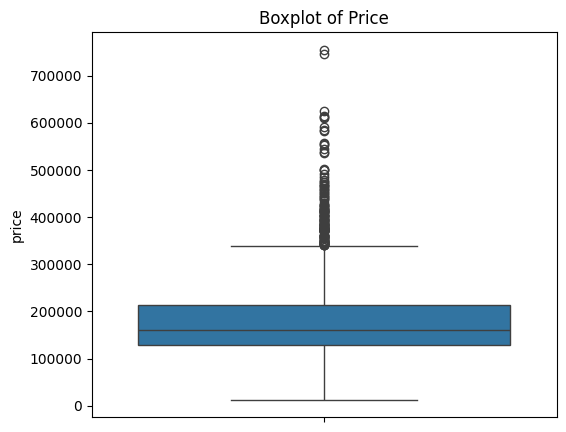

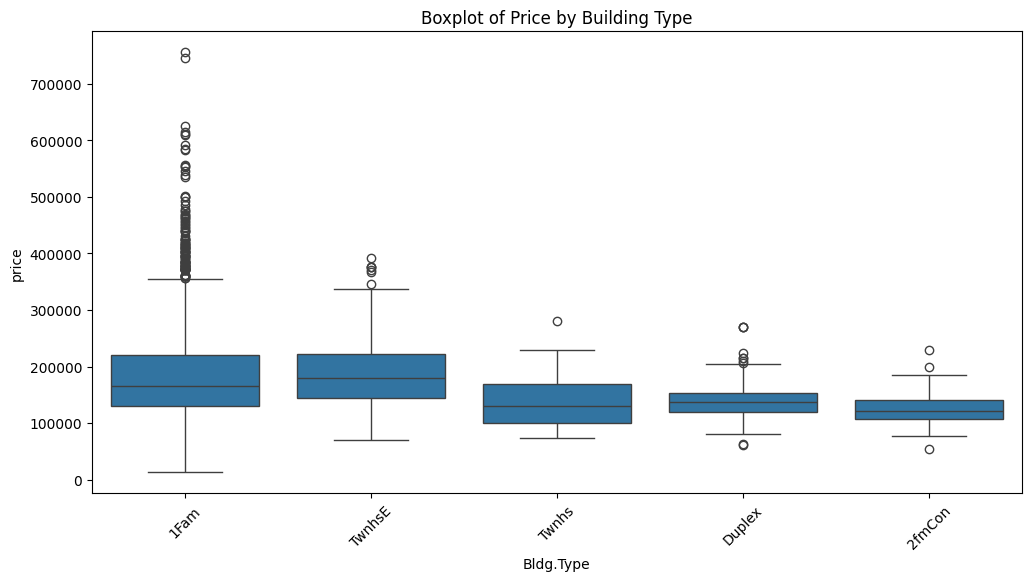

price_outlier
0    2793
1     137
Name: count, dtype: int64


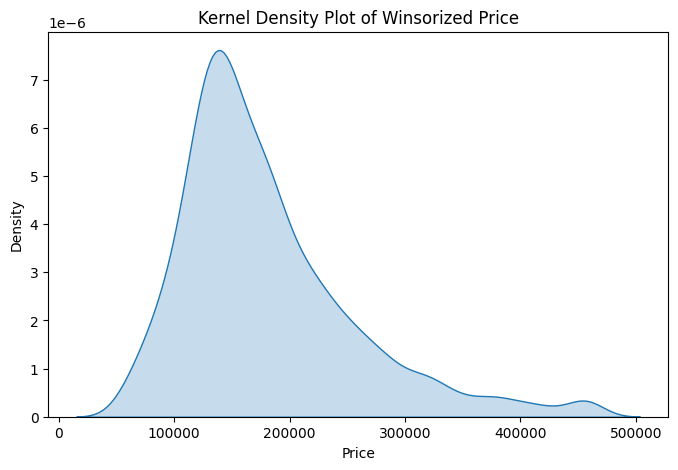

count      2930.000000
mean     180095.501365
std       75872.123444
min       61500.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      457347.000000
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


In [21]:
# 1
df = pd.read_csv('data/ames_prices.csv')

# 2
plt.figure(figsize=(8,5))
sns.kdeplot(df['price'], fill=True)
plt.title("Kernel Density Plot of Price")
plt.xlabel("Price")
plt.ylabel("Density")
plt.show()

print(df['price'].describe())

plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='price', hue='Bldg.Type', fill=True)
plt.title("Kernel Density Plot of Price by Building Type")
plt.xlabel("Price")
plt.ylabel("Density")
plt.show()

type_summary = df.groupby('Bldg.Type')['price'].describe()
print(type_summary[['count','mean','std','min','25%','50%','75%','max']])

# 3
sorted_prices = np.sort(df['price'])
ecdf = np.arange(1, len(sorted_prices)+1) / len(sorted_prices)

plt.figure(figsize=(8,5))
plt.plot(sorted_prices, ecdf, marker='.', linestyle='none')
plt.title("ECDF of Price")
plt.xlabel("Price")
plt.ylabel("ECDF")
plt.show()

five_num = df['price'].quantile([0, 0.25, 0.5, 0.75, 1])
print(five_num)

# 4
plt.figure(figsize=(6,5))
sns.boxplot(y=df['price'])
plt.title("Boxplot of Price")
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(x='Bldg.Type', y='price', data=df)
plt.title("Boxplot of Price by Building Type")
plt.xticks(rotation=45)
plt.show()

# 5

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

df['price_outlier'] = ((df['price'] < (Q1 - 1.5*IQR)) |
                       (df['price'] > (Q3 + 1.5*IQR))).astype(int)

print(df['price_outlier'].value_counts())

# 6

from scipy.stats.mstats import winsorize

# Winsorize at 1% and 99% (clip extremes)
price_wins = winsorize(df['price'], limits=[0.01, 0.01])

# KDE after winsorization
plt.figure(figsize=(8,5))
sns.kdeplot(price_wins, fill=True)
plt.title("Kernel Density Plot of Winsorized Price")
plt.xlabel("Price")
plt.ylabel("Density")
plt.show()

# Describe after winsorization
price_wins_series = pd.Series(price_wins)
print(price_wins_series.describe())
